In [2]:
import numpy as np 
import pandas as pd 
import statsmodels.api as sm 
import statsmodels.formula.api as smf 
from statsmodels.tools.sm_exceptions import ConvergenceWarning 


In [3]:
#load data 
path_stats = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\run_sem\stats_with_ratio.csv"
stats = pd.read_csv(path_stats)

def filter_stats(tag):
    '''Filters the stats dataframe for a given tag and returns the validation set after the 3rd epoch'''
    stats_filtered = stats[(stats['tag'].str.contains(tag)) & (stats['is_train'] == False) & (stats['epoch'] == 3) 
                        & (stats['grain'] == 'fine')]
    stats_uncertainty = stats_filtered.drop_duplicates(subset=['tag'])
    print(stats_uncertainty)
    return stats_uncertainty 

df_uncertainty_hand = filter_stats('mar_12_uncertainty_hand')
df_uncertainty_attention = filter_stats('mar_9_uncertainty_attention')
df_pe_attention = filter_stats('mar_10_pe_attention')




                run grain    bicorr  percentile_to_human  n_event_models  \
13997  6.3.9_kinect  fine  0.283591             3.703704              18   
14007  1.2.3_kinect  fine  0.306868             5.263158              29   
14023  2.4.1_kinect  fine  0.639858            29.166667              28   
14027  3.1.3_kinect  fine  0.573535             8.695652              16   
14045  2.4.1_kinect  fine  0.636766            29.166667              26   
14049  1.2.3_kinect  fine  0.147762             0.000000              26   
14067  2.4.1_kinect  fine  0.547264            20.833333              20   
14069  1.2.3_kinect  fine  0.349625             5.263158              18   
14073  6.3.9_kinect  fine  0.216843             0.000000              19   
14091  1.2.3_kinect  fine  0.327789             5.263158              30   
14095  1.2.3_kinect  fine  0.329741             5.263158              31   
14107  6.3.9_kinect  fine  0.361637             3.703704              17   
14119  3.1.3

In [57]:
median_uncertainty_hand = df_uncertainty_hand['mi'].median()
median_uncertainty_attention = df_uncertainty_attention['mi'].median()

print(median_uncertainty_hand, median_uncertainty_attention)

0.3330656711562868 0.3653405179662549


In [28]:
median_pe_attention = df_pe_attention['n_boundaries'].median()
print(median_pe_attention)


13.5


Linear Mixed Model


In [4]:
df_uncertainty_hand['condition'] = 'hand'
df_uncertainty_attention['condition'] = 'attention'
df_pe_attention['condition'] = 'pe' 
combined_df_uncertainty = pd.concat([df_uncertainty_hand, df_uncertainty_attention])
# combined_df_attention = pd.concat([df_uncertainty_attention, df_pe_attention]) 
print(combined_df_uncertainty)
# print(combined_df_attention)

                run grain    bicorr  percentile_to_human  n_event_models  \
13997  6.3.9_kinect  fine  0.283591             3.703704              18   
14007  1.2.3_kinect  fine  0.306868             5.263158              29   
14023  2.4.1_kinect  fine  0.639858            29.166667              28   
14027  3.1.3_kinect  fine  0.573535             8.695652              16   
14045  2.4.1_kinect  fine  0.636766            29.166667              26   
14049  1.2.3_kinect  fine  0.147762             0.000000              26   
14067  2.4.1_kinect  fine  0.547264            20.833333              20   
14069  1.2.3_kinect  fine  0.349625             5.263158              18   
14073  6.3.9_kinect  fine  0.216843             0.000000              19   
14091  1.2.3_kinect  fine  0.327789             5.263158              30   
14095  1.2.3_kinect  fine  0.329741             5.263158              31   
14107  6.3.9_kinect  fine  0.361637             3.703704              17   
14119  3.1.3

In [11]:
model = smf.mixedlm("mi ~ condition", data=combined_df_uncertainty, groups=combined_df_uncertainty['run'])
res = model.fit() 
print(res.summary())

# model = smf.mixedlm("mi ~ condition", data=combined_df_attention, groups=combined_df_attention['run'])
# res = model.fit() 
# print(res.summary())

          Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  mi     
No. Observations:    48       Method:              REML   
No. Groups:          4        Scale:               0.0186 
Min. group size:     12       Log-Likelihood:      20.7053
Max. group size:     12       Converged:           Yes    
Mean group size:     12.0                                 
----------------------------------------------------------
                  Coef. Std.Err.   z   P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept         0.338    0.049 6.921 0.000  0.242  0.433
condition[T.hand] 0.008    0.039 0.198 0.843 -0.069  0.085
Group Var         0.006    0.049                          



c:\Users\super\anaconda3\envs\sem-viz-jupyter\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
model = smf.mixedlm("bicorr ~ condition", data=combined_df_uncertainty, groups=combined_df_uncertainty['run'])
res_bicorr = model.fit() 
print(res.summary())



           Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   bicorr 
No. Observations:    48        Method:               REML   
No. Groups:          4         Scale:                0.0098 
Min. group size:     12        Log-Likelihood:       33.7534
Max. group size:     12        Converged:            Yes    
Mean group size:     12.0                                   
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.495    0.060  8.313 0.000  0.378  0.611
condition[T.hand] -0.032    0.029 -1.126 0.260 -0.088  0.024
Group Var          0.013    0.114                           



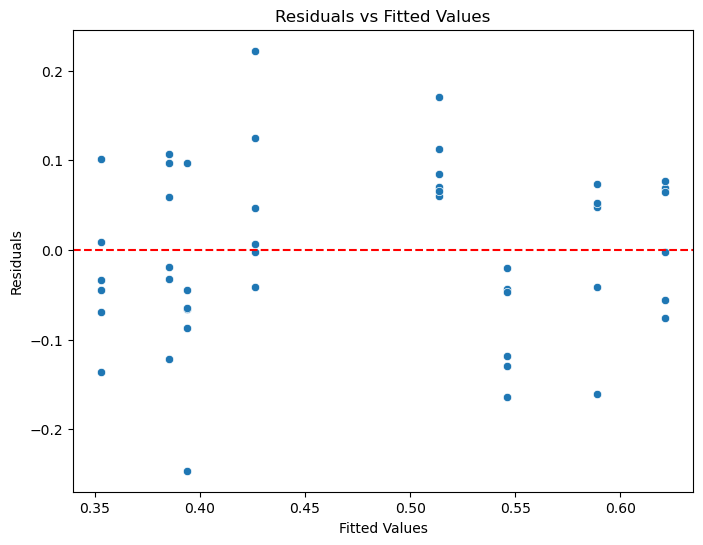

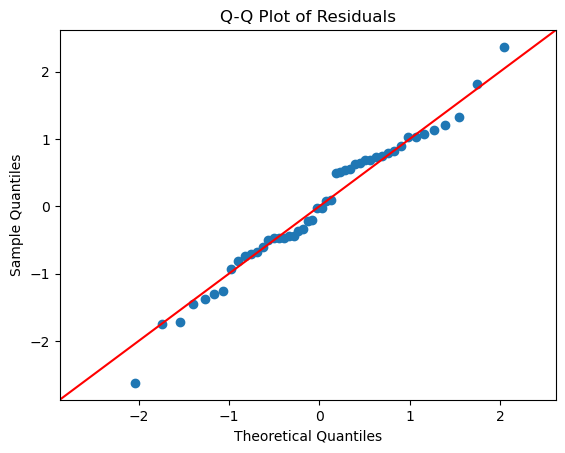

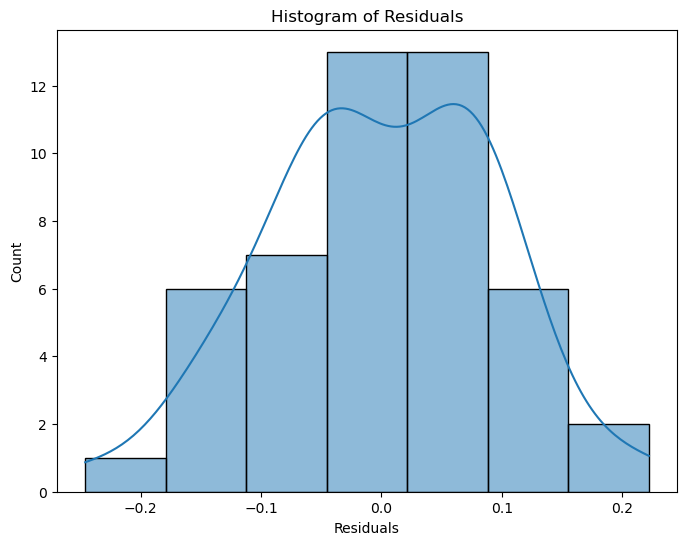

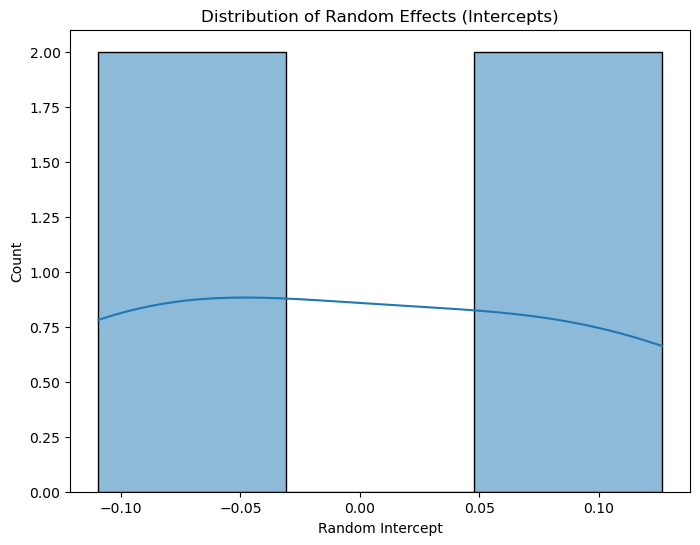

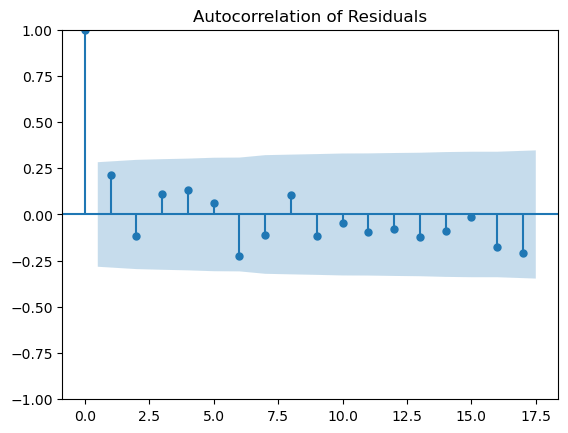

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

def plot_assumptions(res):
    fitted_vals = res.fittedvalues
    residuals = res.resid

    # 1. Residuals vs Fitted Values (for linearity and homoscedasticity)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=fitted_vals, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Fitted Values")
    plt.show()

    # 2. Q-Q Plot for residuals (normality)
    sm.qqplot(residuals, line='45', fit=True)
    plt.title("Q-Q Plot of Residuals")
    plt.show()

    # 3. Histogram of residuals (normality)
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True)
    plt.xlabel("Residuals")
    plt.title("Histogram of Residuals")
    plt.show()

    # 4. Check random effects: extract random intercepts if available
    # (res.random_effects is a dictionary; we'll plot the random intercepts)
    random_intercepts = [v[list(v.keys())[0]] for v in res.random_effects.values()]
    plt.figure(figsize=(8, 6))
    sns.histplot(random_intercepts, kde=True)
    plt.title("Distribution of Random Effects (Intercepts)")
    plt.xlabel("Random Intercept")
    plt.show()

    # 5. If applicable, you might also plot autocorrelation of residuals:
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(residuals)
    plt.title("Autocorrelation of Residuals")
    plt.show()
plot_assumptions(res)